## Environment & Dependencies

**Python 3.x** required. Install all dependencies with:
```
pip install pandas numpy matplotlib scipy scikit-learn statsmodels
```

**Data files** required in the same directory as this notebook:
- `events.csv` — raw Retailrocket clickstream event log (primary dataset)
- `item_properties_part1.csv` / `item_properties_part2.csv` — item attribute tables (used to infer product price)

# Retailrocket E-Commerce Dataset — Purchase Decision Analysis

## 0. Upload and Load the Dataset

In [ ]:
# If running on Google Colab, upload data files manually or mount Google Drive:
# from google.colab import files
# files.upload()  # upload events.csv, item_properties_part1.csv, item_properties_part2.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("events.csv")

## 1. Basic Data Information

In [2]:
print("=== Data Dimensions ===")
print(df.shape)

=== Data Dimensions ===
(2756101, 5)


In [3]:
print("=== Data Types ===")
print(df.dtypes)

=== Data Types ===
timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object


In [4]:
print("=== Non-Null Value Counts ===")
print(df.notnull().sum())

=== Non-Null Value Counts ===
timestamp        2756101
visitorid        2756101
event            2756101
itemid           2756101
transactionid      22457
dtype: int64


In [5]:
print("=== Descriptive Statistics ===")
df.describe()

=== Descriptive Statistics ===


,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [6]:
print("=== Event Type Distribution ===")
df["event"].value_counts()

=== Event Type Distribution ===


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

## 2. Data Cleaning

In [7]:
# Convert timestamp to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# Filter out buyers who had a transaction event, and their related events
buyers = df[df['event'] == 'transaction']['visitorid'].unique()
buyer_events = df[df['visitorid'].isin(buyers)]

# Construct the analysis unit (visitorid + itemid), keeping only item combinations that actually had a transaction
# (otherwise items the user merely browsed but never bought would get mixed in, leaving no purchase moment,
#  so decision_hours could not be calculated and would become NaN)
# Using a single customer as the analysis unit would flatten out the heterogeneity across that same user's
# different purchase decisions, so the analysis unit built here is the visitorid+itemid combination
buyer_events = buyer_events.sort_values('timestamp')
has_purchase = buyer_events.groupby(['visitorid', 'itemid'])['event'].transform(lambda s: (s == 'transaction').any())
purchase_events = buyer_events[has_purchase]
units = purchase_events.groupby(['visitorid', 'itemid'])

print("Number of buyers:", len(buyers))
print("Number of buyer-related events:", len(buyer_events))
print("Number of analysis units (visitorid+itemid, with purchase):", units.ngroups)

# Drop the transactionid column
# The decision process of each transaction has already been aggregated via the visitorid+itemid analysis unit,
# so the transactionid information is redundant and is dropped
buyer_events = buyer_events.drop(columns=['transactionid'])

# Descriptive statistics (after cleaning)
print(buyer_events.describe())
print(buyer_events['event'].value_counts())

# Save the cleaned result
buyer_events.to_csv("events2.csv", index=False)

Number of buyers: 11719
Number of buyer-related events: 230678
Number of analysis units (visitorid+itemid, with purchase): 21270
                           timestamp     visitorid         itemid
count                         230678  2.306780e+05  230678.000000
mean   2015-07-07 19:12:24.753529344  6.875363e+05  235667.187881
min       2015-05-03 03:03:20.404000  1.720000e+02      15.000000
25%    2015-06-04 17:35:07.609999872  3.395260e+05  119736.000000
50%    2015-07-07 15:51:38.306000128  6.868540e+05  238386.000000
75%    2015-08-06 19:38:36.672249856  1.030808e+06  351547.500000
max       2015-09-18 02:52:21.219000  1.407398e+06  466864.000000
std                              NaN  3.995951e+05  134887.786350
event
view           180754
addtocart       27467
transaction     22457
Name: count, dtype: int64


## 3. Construct Core Variables

In [8]:
# decision_hours: time gap between the first view and the first transaction (hours), representing decision duration
# research_views: number of views before purchase, representing the degree of information gathering
# has_addtocart: whether the item was added to cart before purchase (0/1), representing a purchase-behavior signal
# view_interval_mean: mean interval between consecutive views (hours), handling logic:
#   research_views == 0 -> NaN (no browsing record, variable is meaningless)
#   research_views == 1 -> 0 (a single view, so the interval is zero)
#   research_views >= 2 -> actual computed value (mean interval across multiple views)
def unit_features(g):
    first_trans = g.loc[g['event'] == 'transaction', 'timestamp'].min()
    pre_views = g.loc[(g['event'] == 'view') & (g['timestamp'] < first_trans), 'timestamp']
    first_view = pre_views.min() if len(pre_views) > 0 else pd.NaT
    decision_hours = (first_trans - first_view).total_seconds() / 3600 if pd.notna(first_view) else np.nan
    research_views = len(pre_views)
    has_addtocart = int((g['event'].eq('addtocart') & (g['timestamp'] < first_trans)).any())

    if research_views == 0:
        view_interval_mean = np.nan
    elif research_views == 1:
        view_interval_mean = 0
    else:
        view_interval_mean = pre_views.diff().dropna().dt.total_seconds().mean() / 3600

    return pd.Series({
        'first_trans': first_trans,
        'decision_hours': decision_hours,
        'research_views': research_views,
        'has_addtocart': has_addtocart,
        'view_interval_mean': view_interval_mean
    })

data = units.apply(unit_features, include_groups=False).reset_index()

# Drop records where research_views == 0
# Having a transaction but no pre-purchase view leaves only two possibilities:
#   1) the user must open an item at least once on the platform before buying, so a missing view record is a
#      data anomaly (missing data);
#   2) the user purchased directly via an external link, so the information gathering happened off-platform and
#      the decision was already formed by the time they entered the platform (the decision happened off-platform).
# Either way, the decision path of these records is unobservable within this dataset, so they are dropped.
data = data[data['research_views'] > 0]

# total_purchases / active_days / unique_items_viewed: use the cumulative value "as of this decision",
# not the visitor's entire history (using the entire history would also count events that happen after this
# decision, i.e. describing the experience state at the time of the decision using future information,
# which is data leakage — see the key limitations section in Note2 for details)

# total_purchases: the number of purchases this visitor had already completed before this first_trans
# (not including this one), representing purchase experience
trans_times = buyer_events.loc[buyer_events['event'] == 'transaction', ['visitorid', 'timestamp']].sort_values(['visitorid', 'timestamp']).copy()
trans_times['total_purchases'] = trans_times.groupby('visitorid').cumcount()
trans_times = trans_times.drop_duplicates(subset=['visitorid', 'timestamp'])
data = data.merge(trans_times[['visitorid', 'timestamp', 'total_purchases']],
                   left_on=['visitorid', 'first_trans'], right_on=['visitorid', 'timestamp'], how='left')
data = data.drop(columns=['timestamp'])

# active_days: this first_trans minus the visitor's earliest event time (the endpoint is changed to this decision's
# time point instead of the last event of the entire history), representing the number of active days
visitor_first_event = buyer_events.groupby('visitorid')['timestamp'].min().rename('visitor_first_event')
data = data.merge(visitor_first_event, on='visitorid', how='left')
data['active_days'] = (data['first_trans'] - data['visitor_first_event']).dt.total_seconds() / 86400
data = data.drop(columns=['visitor_first_event'])

# unique_items_viewed: the number of distinct items this visitor had viewed as of this decision
# (including the item viewed in this decision itself), representing the breadth of information gathering
view_events = buyer_events.loc[buyer_events['event'] == 'view', ['visitorid', 'itemid', 'timestamp']].sort_values(['visitorid', 'timestamp']).copy()

def running_unique(g):
    seen = set()
    out = []
    for it in g['itemid']:
        seen.add(it)
        out.append(len(seen))
    return pd.Series(out, index=g.index)

view_events['running_unique'] = view_events.groupby('visitorid', group_keys=False).apply(running_unique)

data = data.sort_values('first_trans')
unique_lookup = view_events[['visitorid', 'timestamp', 'running_unique']].sort_values('timestamp')
data = pd.merge_asof(data, unique_lookup, left_on='first_trans', right_on='timestamp',
                      left_by='visitorid', right_by='visitorid', direction='backward')
data = data.rename(columns={'running_unique': 'unique_items_viewed'}).drop(columns=['timestamp'])
data['unique_items_viewed'] = data['unique_items_viewed'].fillna(0).astype(int)

data = data.reset_index(drop=True)
data.head()

# Save the result after constructing the core variables
data.to_csv("events3.csv", index=False)

C:\Users\dell\AppData\Local\Temp\ipykernel_132\1014324429.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  view_events['running_unique'] = view_events.groupby('visitorid', group_keys=False).apply(running_unique)


In [9]:
# view_interval_mean is excluded from the main analysis because its share of structural zero values is too high
# (it is forced to 0 or NaN whenever research_views<=1); it is kept in the raw constructed data (events3.csv)
# for use in the later subsample analysis
data4 = data.drop(columns=['view_interval_mean'])
data4.to_csv("events4.csv", index=False)

print("=== Data Dimensions ===")
print(data4.shape)

print("=== Non-Null Value Counts ===")
print(data4.notnull().sum())

print("=== Data Types ===")
print(data4.dtypes)

print("=== Descriptive Statistics ===")
data4.describe()

=== Data Dimensions ===
(18738, 9)
=== Non-Null Value Counts ===
visitorid              18738
itemid                 18738
first_trans            18738
decision_hours         18738
research_views         18738
has_addtocart          18738
total_purchases        18738
active_days            18738
unique_items_viewed    18738
dtype: int64
=== Data Types ===
visitorid                       int64
itemid                          int64
first_trans            datetime64[ns]
decision_hours                float64
research_views                  int64
has_addtocart                   int64
total_purchases                 int64
active_days                   float64
unique_items_viewed             int64
dtype: object
=== Descriptive Statistics ===


,visitorid,itemid,first_trans,decision_hours,research_views,has_addtocart,total_purchases,active_days,unique_items_viewed
count,1.873800e+04,18738.000000,18738,18738.000000,18738.000000,18738.000000,18738.000000,18738.000000,18738.000000
mean,6.987495e+05,236575.196606,2015-07-08 21:08:36.274203136,24.430733,2.012221,0.909169,21.888996,9.648164,163.361031
min,1.720000e+02,15.000000,2015-05-03 03:27:21.391000,0.003012,1.000000,0.000000,0.000000,0.000125,1.000000
25%,3.455585e+05,120990.000000,2015-06-05 15:58:39.231500032,0.065214,1.000000,1.000000,0.000000,0.009439,1.000000
50%,7.055420e+05,239006.000000,2015-07-08 15:52:31.814500096,0.158011,1.000000,1.000000,0.000000,0.157822,4.000000
75%,1.062192e+06,352718.500000,2015-08-09 02:19:59.696499968,0.732350,2.000000,1.000000,7.000000,9.003925,59.000000
max,1.407110e+06,466861.000000,2015-09-18 02:43:12.017000,3143.499146,114.000000,1.000000,558.000000,135.459702,3801.000000
std,4.042375e+05,135033.753206,NaN,129.829082,2.218374,0.287377,63.979728,20.067456,439.066135


In [10]:
# Product price (price): property 790, inferred from the item_properties dataset, very likely denotes price
# (see the Future Work section of Note2 for the rationale); this cannot be confirmed with 100% certainty, so it is
# called an "inferred price" and is for reference only
# Time-aware matching is performed against the purchase timestamp to attach price/log_price onto data4
# Note: price is a product attribute, not a feature of the user's decision behavior itself, so it is not included
# in the later clustering (cluster_vars does not contain it); it is only used in the Section 7 regression analysis
# to compare the "with price vs. without price" models, and to look at price differences across clusters after
# clustering is done
# first_trans was already constructed in Section 3 and is kept in data4, so it is reused directly here instead of
# being recomputed from events2

# price.csv: price inferred from property=790, with the sentinel value already removed; here price=0 is also
# excluded (interpreted as an outlier or a free gift, whose decision path differs from normally priced items)
price_df = pd.read_csv('price.csv', parse_dates=['timestamp'])
price_df = price_df[price_df['price'] > 0].sort_values('timestamp')

# Time-aware matching: use merge_asof to take, for each item, the most recent price before the purchase time
# (grouped by itemid, looking backward)
merge_base = data4[['visitorid', 'itemid', 'first_trans']].sort_values('first_trans')

price_matched = pd.merge_asof(
    merge_base,
    price_df,
    left_on='first_trans', right_on='timestamp',
    left_by='itemid', right_by='itemid',
    direction='backward'
)
print(f"Proportion of records matched to a price: {price_matched['price'].notna().mean():.2%}")

data4 = data4.merge(price_matched[['visitorid', 'itemid', 'price']], on=['visitorid', 'itemid'], how='left')
data4['log_price'] = np.log1p(data4['price'])
print(f"price missing rate: {data4['price'].isna().mean():.2%}")
# The missing rate is acceptable, mainly because some items had no corresponding property 790 price record at the
# time of purchase (possibly promotional items, purchases via external links, etc.), a limitation of the inferred
# data itself.

Proportion of records matched to a price: 91.30%
price missing rate: 8.70%


## 4. Descriptive Statistics (Raw Values)

In [11]:
# -- 4. Descriptive Statistics (Raw Values) --------------------------------

def describe_var(s, name):
    print(f"--- {name} ---")
    print(f"Mean: {s.mean():.3f}, Median: {s.median():.3f}, Std: {s.std():.3f}, "
          f"Q1: {s.quantile(0.25):.3f}, Q3: {s.quantile(0.75):.3f}, Skewness: {s.skew():.3f}")

raw_vars = ['decision_hours', 'research_views', 'total_purchases', 'active_days', 'unique_items_viewed']
skew_raw = {}
for col in raw_vars:
    describe_var(data4[col], col)
    skew_raw[col] = data4[col].skew()

# Identify right-skewed variables: skewness > 1 is treated as clearly right-skewed, meaning these variables'
# distributions have a long tail (extreme high values), which may need a log transform or other treatment to
# improve model performance.
print("Right-skewed variables (skewness > 1):", [c for c, sk in skew_raw.items() if sk > 1])

# has_addtocart frequency and proportion
print(data4['has_addtocart'].value_counts())
print(data4['has_addtocart'].value_counts(normalize=True).round(3))

# research_views binned frequency and proportion (illustrates why these bins make sense: samples with 4+ views
# are sparse and long-tailed)
rv_bins = [0, 1, 3, data4['research_views'].max()]
rv_labels = ['Single view (1)', 'Few views (2-3)', 'Many views (4+)']
rv_bin_preview = pd.cut(data4['research_views'], bins=rv_bins, labels=rv_labels, right=True)
print(rv_bin_preview.value_counts())
print(rv_bin_preview.value_counts(normalize=True).round(3))

# Note on the structural missingness of view_interval_mean
# When research_views=1, this column is structurally set to 0 (only one view, so there is no adjacent interval
# to compute), which is structural missingness rather than missing-at-random, so it is not imputed and is not
# included in the main analysis
data3 = pd.read_csv("events3.csv")
single_view_count = (data3['research_views'] == 1).sum()
single_view_ratio = (data3['research_views'] == 1).mean()
print(f"Number of records with research_views=1: {single_view_count}, proportion: {single_view_ratio:.3f}")

--- decision_hours ---
Mean: 24.431, Median: 0.158, Std: 129.829, Q1: 0.065, Q3: 0.732, Skewness: 9.956
--- research_views ---
Mean: 2.012, Median: 1.000, Std: 2.218, Q1: 1.000, Q3: 2.000, Skewness: 15.969
--- total_purchases ---
Mean: 21.889, Median: 0.000, Std: 63.980, Q1: 0.000, Q3: 7.000, Skewness: 4.693
--- active_days ---
Mean: 9.648, Median: 0.158, Std: 20.067, Q1: 0.009, Q3: 9.004, Skewness: 2.959
--- unique_items_viewed ---
Mean: 163.361, Median: 4.000, Std: 439.066, Q1: 1.000, Q3: 59.000, Skewness: 4.438
Right-skewed variables (skewness > 1): ['decision_hours', 'research_views', 'total_purchases', 'active_days', 'unique_items_viewed']
has_addtocart
1    17036
0     1702
Name: count, dtype: int64
has_addtocart
1    0.909
0    0.091
Name: proportion, dtype: float64
research_views
Single view (1)    10238
Few views (2-3)     6348
Many views (4+)     2152
Name: count, dtype: int64
research_views
Single view (1)    0.546
Few views (2-3)    0.339
Many views (4+)    0.115
Name: prop

## 5. Variable Transformation

In [12]:
# -- 5. Variable Transformation ---------------------------------------------

# decision_hours, research_views, total_purchases, active_days, unique_items_viewed -> log1p transform to
# address right skew and reduce the influence of extreme values
# The original columns are kept; new log_-prefixed columns are added for clustering and regression
for col in raw_vars:
    data4[f'log_{col}'] = np.log1p(data4[col])

# has_addtocart is a binary variable, so it is not transformed

# research_views -> research_views_bin, binned for descriptive statistics and report display only, not used
# for clustering
data4['research_views_bin'] = pd.cut(data4['research_views'], bins=rv_bins, labels=rv_labels, right=True)

## 6. Descriptive Statistics (After Transformation)

--- log_decision_hours ---
Mean: 0.805, Median: 0.147, Std: 1.490, Skewness: 2.397
--- log_research_views ---
Mean: 0.995, Median: 0.693, Std: 0.410, Skewness: 1.607
--- log_total_purchases ---
Mean: 1.144, Median: 0.000, Std: 1.732, Skewness: 1.301
--- log_active_days ---
Mean: 1.137, Median: 0.147, Std: 1.449, Skewness: 0.948
--- log_unique_items_viewed ---
Mean: 2.582, Median: 1.609, Std: 2.166, Skewness: 0.964
                     skewness_before  skewness_after
decision_hours              9.955957        2.397193
research_views             15.969498        1.606580
total_purchases             4.693006        1.300768
active_days                 2.958855        0.947538
unique_items_viewed         4.437923        0.963879


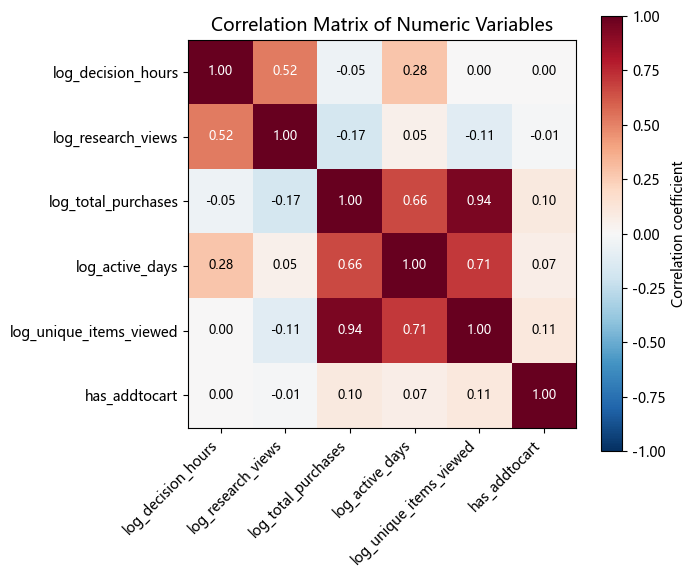

                         log_decision_hours  log_research_views  \
log_decision_hours                    1.000               0.523   
log_research_views                    0.523               1.000   
log_total_purchases                  -0.052              -0.172   
log_active_days                       0.279               0.052   
log_unique_items_viewed               0.004              -0.110   
has_addtocart                         0.002              -0.008   

                         log_total_purchases  log_active_days  \
log_decision_hours                    -0.052            0.279   
log_research_views                    -0.172            0.052   
log_total_purchases                    1.000            0.656   
log_active_days                        0.656            1.000   
log_unique_items_viewed                0.940            0.708   
has_addtocart                          0.096            0.069   

                         log_unique_items_viewed  has_addtocart  
log_deci

In [13]:
# -- 6. Descriptive Statistics (After Transformation) -----------------------

log_vars = [f'log_{col}' for col in raw_vars]
skew_log = {}
for col in log_vars:
    print(f"--- {col} ---")
    print(f"Mean: {data4[col].mean():.3f}, Median: {data4[col].median():.3f}, "
          f"Std: {data4[col].std():.3f}, Skewness: {data4[col].skew():.3f}")
    skew_log[col] = data4[col].skew()

# Compare skewness before and after the transform to confirm the improvement
skew_compare = pd.DataFrame({
    'skewness_before': skew_raw,
    'skewness_after': {col.replace('log_', ''): sk for col, sk in skew_log.items()}
})
print(skew_compare)

# Candidate list of clustering variables
cluster_vars = ['log_decision_hours', 'log_research_views', 'log_total_purchases',
                'log_active_days', 'log_unique_items_viewed', 'has_addtocart']

# Pairwise correlation matrix of numeric variables (heatmap)
# The correlation matrix itself is a tool for describing data structure, so it is done right after the
# descriptive statistics rather than waiting until just before clustering to check collinearity
corr_matrix = data4[cluster_vars].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(cluster_vars)))
ax.set_yticks(range(len(cluster_vars)))
ax.set_xticklabels(cluster_vars, rotation=45, ha='right')
ax.set_yticklabels(cluster_vars)

for i in range(len(cluster_vars)):
    for j in range(len(cluster_vars)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.5 else 'black', fontsize=9)

fig.colorbar(im, ax=ax, label='Correlation coefficient')
ax.set_title('Correlation Matrix of Numeric Variables', fontsize=13)
plt.tight_layout()
plt.show()

print(corr_matrix.round(3))

# Collinearity found: log_total_purchases and log_unique_items_viewed have a correlation as high as 0.94
# This is a necessary behavioral association (the more someone buys, the more product types they naturally
# browse), not a problem with how the variables are designed, but including both in clustering would let the
# same information be counted twice, so one of the two needs to be chosen
# Criterion 1 (business meaning): log_total_purchases directly reflects purchase experience, corresponding
#   directly to Sub-Hypothesis 1 "the more experienced, the faster the decision"; log_unique_items_viewed
#   reflects exploration breadth, which is only an indirect expression of purchase experience
# Criterion 2 (distinctiveness from other variables): log_total_purchases has a correlation of 0.656 with
#   log_active_days, while log_unique_items_viewed has a higher correlation of 0.708 with log_active_days,
#   meaning unique_items_viewed's information is already more covered by active_days, so its marginal value
#   is lower
# Conclusion: drop log_unique_items_viewed, keep log_total_purchases
cluster_vars.remove('log_unique_items_viewed')
print("Clustering variables (after removing collinearity):", cluster_vars)

## 7. Regression Analysis (Optional)

In [14]:
# Dependent variable: log_decision_hours
# Model 1 (core behavioral variables): log_research_views, has_addtocart, log_total_purchases, log_active_days
#   does not include log_unique_items_viewed -- consistent with the Section 6 clustering treatment: it is
#   collinear with log_total_purchases (r=0.94)
# Model 2: Model 1 + log_price (drops the 8.7% of samples missing price, so both models are compared on the
#   same sample for fairness)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm

feat1 = ['log_research_views', 'has_addtocart', 'log_total_purchases', 'log_active_days']
feat2 = feat1 + ['log_price']

data_p = data4.dropna(subset=['log_price'])  # Model 2 needs price; both models are run on this sample for comparability

# VIF check: confirm there is no severe multicollinearity
vif = pd.Series(
    [variance_inflation_factor(sm.add_constant(data_p[feat1]).values, i) for i in range(len(feat1) + 1)],
    index=['const'] + feat1
)
print("=== VIF (Model 1 features) ===")
print(vif)

ols1 = sm.OLS(data_p['log_decision_hours'], sm.add_constant(data_p[feat1])).fit()
ols2 = sm.OLS(data_p['log_decision_hours'], sm.add_constant(data_p[feat2])).fit()

print("\n=== Model 1 (OLS) ===")
print(ols1.summary())
print("\n=== Model 2 (OLS, +price) ===")
print(ols2.summary())

print("\n=== Nested model F-test: does adding price significantly improve the model? ===")
print(anova_lm(ols1, ols2))

# Comparison of predictive performance across a few common regression methods (5-fold CV R^2, all using the
# Model 2 feature set)
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = data_p[feat2].values
y = data_p['log_decision_hours'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'OLS (approx., Ridge alpha->0)': make_pipeline(StandardScaler(), Ridge(alpha=1e-4)),
    'Ridge (alpha=1.0)': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso (alpha=0.01)': make_pipeline(StandardScaler(), Lasso(alpha=0.01)),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
}

print("\n=== 5-fold cross-validation R^2 (predictive performance comparison) ===")
for name, model in candidates.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(f"{name:28s} R^2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Lasso standardized coefficients: check whether has_addtocart is shrunk to 0 (an independent check of the
# OLS conclusion that it is not significant)
lasso = Lasso(alpha=0.01)
lasso.fit(StandardScaler().fit_transform(X), y)
print("\n=== Lasso standardized coefficients ===")
for f, c in zip(feat2, lasso.coef_):
    print(f"{f:25s} {c:.4f}")
# has_addtocart's coefficient is shrunk to 0, indicating its predictive contribution to log_decision_hours is
# not significant, consistent with the OLS result.

=== VIF (Model 1 features) ===
const                  17.914923
log_research_views      1.084779
has_addtocart           1.009684
log_total_purchases     1.908792
log_active_days         1.847219
dtype: float64

=== Model 1 (OLS) ===
                            OLS Regression Results                            
Dep. Variable:     log_decision_hours   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     2506.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:32:28   Log-Likelihood:                -27314.
No. Observations:               17107   AIC:                         5.464e+04
Df Residuals:                   17102   BIC:                         5.468e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                  

## 8. Four-Quadrant EDA

quadrant
Decisive           7273
Cautious           6404
Procrastinating    2965
Intensive          2096
Name: count, dtype: int64
quadrant
Decisive           0.388
Cautious           0.342
Procrastinating    0.158
Intensive          0.112
Name: proportion, dtype: float64
                 decision_hours  research_views  total_purchases  active_days  \
quadrant                                                                        
Decisive               0.059516             1.0              1.0     0.264138   
Cautious               1.304681             3.0              0.0     0.380166   
Procrastinating        0.356866             1.0              0.0     0.039375   
Intensive              0.090323             2.0              0.0     0.122132   

                 unique_items_viewed  has_addtocart  
quadrant                                             
Decisive                         6.0            1.0  
Cautious                         4.0            1.0  
Procrastinating         

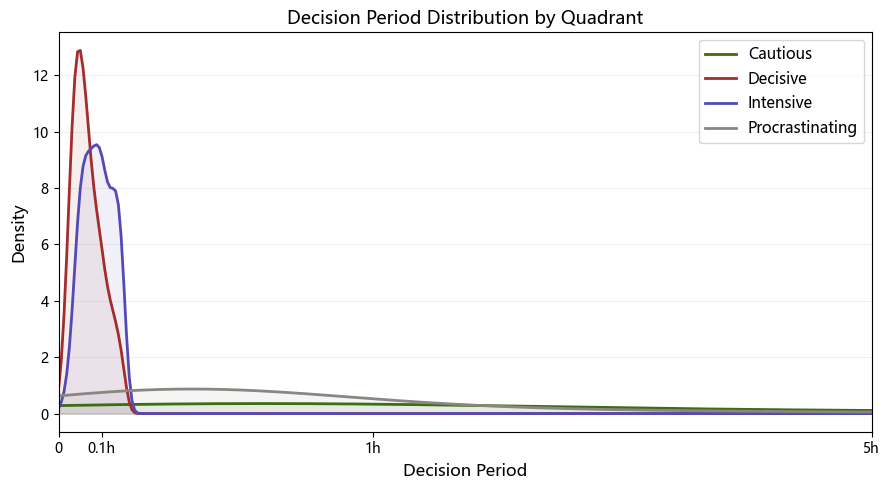

In [15]:
# Use the medians of research_views and decision_hours as the split points
median_rv = data4['research_views'].median()
median_dh = data4['decision_hours'].median()

# Construct the four-quadrant type variable: Decisive (low views + fast decision) / Cautious (high views + slow
# decision) / Procrastinating (low views + slow decision) / Intensive (high views + fast decision)
# Naming note: the original "Impulsive" was renamed to "Decisive" -- this group has the highest median
#   pre-decision purchase experience among the four quadrants (1 time), which is "making a quick call based on
#   experience" rather than "buying without thinking it through"; the word "impulsive" presupposes a negative
#   judgment and is inaccurate;
# the original "Efficient" was renamed to "Intensive" -- "efficient" implies a judgment about decision quality,
#   but this dataset can only measure speed and frequency, not whether the outcome was "good"; "Intensive" only
#   describes the behavior pattern itself: the number of repeat views is not small (2 times) but is compressed
#   into a very short time window (0.090h), forming a clean contrast in "viewing density" against the Cautious
#   type (3 views spread out over a long 1.305h window)
low_rv = data4['research_views'] <= median_rv
low_dh = data4['decision_hours'] <= median_dh
data4['quadrant'] = np.select(
    [low_rv & low_dh, ~low_rv & ~low_dh, low_rv & ~low_dh, ~low_rv & low_dh],
    ['Decisive', 'Cautious', 'Procrastinating', 'Intensive'],
    default=''
)
quadrant_order = ['Decisive', 'Cautious', 'Procrastinating', 'Intensive']

# Distribution and behavioral profile of each quadrant
quadrant_pct = data4['quadrant'].value_counts(normalize=True).reindex(quadrant_order).round(3)
print(data4['quadrant'].value_counts().reindex(quadrant_order))
print(quadrant_pct)
print(data4.groupby('quadrant')[['decision_hours', 'research_views', 'total_purchases',
                                  'active_days', 'unique_items_viewed', 'has_addtocart']]
      .median().reindex(quadrant_order))

# Kruskal-Wallis test: differences in each variable across the four quadrants (validates whether this
# grouping itself is meaningful)
from scipy.stats import kruskal

kw_vars = ['decision_hours', 'research_views', 'total_purchases',
           'active_days', 'unique_items_viewed', 'has_addtocart']

kw_results = []
for col in kw_vars:
    groups = [data4[data4['quadrant'] == q][col] for q in quadrant_order]
    stat, p = kruskal(*groups)
    kw_results.append({'variable': col, 'H_statistic': stat, 'p_value': p})

kw_df = pd.DataFrame(kw_results)
kw_df['significant(p<0.05)'] = kw_df['p_value'] < 0.05
print(kw_df)
# The differences across the four quadrants are significant for every variable, meaning this grouping itself
# is meaningful, i.e. the decision profiles of each type really do differ

# Figure 1: KDE distribution of decision period by quadrant (log axis, ticks converted back to raw hours)
from scipy.stats import gaussian_kde
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'Decisive': '#A32D2D', 'Cautious': '#3B6D11', 'Procrastinating': '#888780', 'Intensive': '#534AB7'}
xs = np.linspace(0, np.log1p(5), 300)

for q, grp in data4.groupby('quadrant'):
    kde = gaussian_kde(grp['log_decision_hours'], bw_method=0.3)
    ax.plot(xs, kde(xs), color=colors[q], linewidth=2, label=q)
    ax.fill_between(xs, kde(xs), alpha=0.08, color=colors[q])

# Convert the x-axis ticks back to raw hours
tick_vals = [0, np.log1p(0.1), np.log1p(1), np.log1p(5)]
tick_labels = ['0', '0.1h', '1h', '5h']
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_labels)
ax.set_xlim(0, np.log1p(5))

ax.set_xlabel('Decision Period', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Decision Period Distribution by Quadrant', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 9. K-Means Clustering

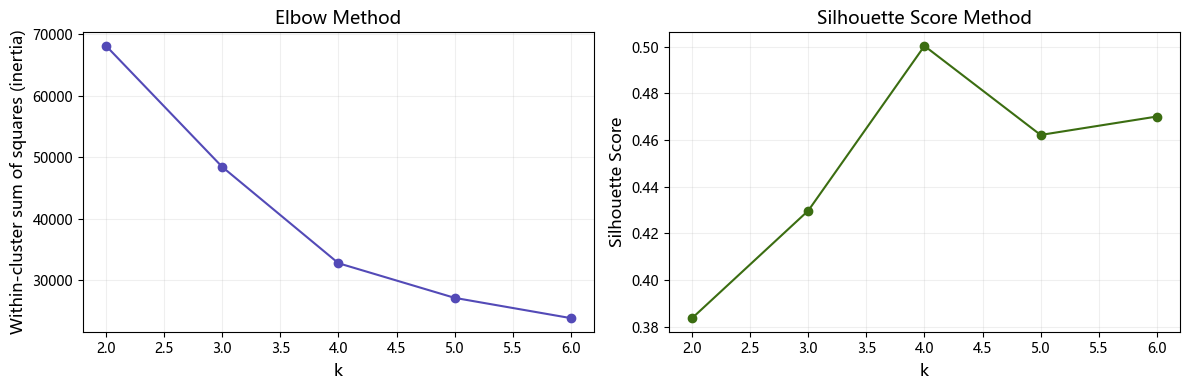

      inertia  silhouette_score
2  68086.2814            0.3837
3  48413.8846            0.4297
4  32772.4210            0.5003
5  27144.1104            0.4621
6  23850.1764            0.4700
Optimal k value: 4 (silhouette score 0.5003)
cluster
0     4532
1    10259
2     2320
3     1627
Name: count, dtype: int64
         decision_hours  research_views  total_purchases  active_days  \
cluster                                                                 
0              0.066046             1.0             39.0    18.010581   
1              0.174864             1.0              0.0     0.015060   
2             65.342725             4.0              0.0     7.023913   
3              0.113367             1.0              0.0     0.018042   

         unique_items_viewed  has_addtocart  
cluster                                      
0                      338.5            1.0  
1                        2.0            1.0  
2                        6.0            1.0  
3               

In [16]:
# Standardization
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = data4[cluster_vars]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method + silhouette score method to determine the optimal k (k=2~6)
inertias = {}
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias[k] = km.inertia_
    sil_scores[k] = silhouette_score(X_scaled, labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(inertias.keys()), list(inertias.values()), marker='o', color='#534AB7')
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('Within-cluster sum of squares (inertia)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].grid(alpha=0.2)

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='#3B6D11')
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score Method', fontsize=13)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(pd.DataFrame({'inertia': inertias, 'silhouette_score': sil_scores}).round(4))

best_k = max(sil_scores, key=sil_scores.get)
print(f"Optimal k value: {best_k} (silhouette score {sil_scores[best_k]:.4f})")

# Clustering result at the optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data4['cluster'] = kmeans.fit_predict(X_scaled)

print(data4['cluster'].value_counts().sort_index())

# Behavioral profile of each cluster
print(data4.groupby('cluster')[['decision_hours', 'research_views', 'total_purchases',
                                 'active_days', 'unique_items_viewed', 'has_addtocart']]
      .median())

## 10. Cluster Result Validation

In [17]:
# Kruskal-Wallis test: differences across clusters in decision_hours
from scipy.stats import kruskal

cluster_order = sorted(data4['cluster'].unique())
groups = [data4[data4['cluster'] == c]['decision_hours'] for c in cluster_order]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis: H={stat:.2f}, p={p:.4g} (significant: {p < 0.05})")

# Comparison between the four quadrants and the clustering result
crosstab = pd.crosstab(data4['cluster'], data4['quadrant']).reindex(columns=quadrant_order)
print(crosstab)

# Observations:
# Cluster 2 (High-Friction Decision) falls almost entirely within the Cautious quadrant, making it the cleanest
#   overlap between the two grouping schemes -- meaning that the decisions with both "high research depth and
#   high decision period" identified by the two methods are essentially the same batch
# Cluster 0 (High-Experience Decision) is mainly in the Decisive quadrant, but is spread across all four
#   quadrants, meaning the "purchase experience" dimension cuts across multiple decision patterns and is not
#   fully captured by the two variables decision_hours/research_views
# Cluster 1 (Lightweight Decision) and Cluster 3 (No-Add-to-Cart Decision) are both fairly evenly spread across
#   the four quadrants, meaning the true distinguishing dimension of these two clusters (whether purchase
#   experience is zero, whether add-to-cart was skipped) has a low association with decision_hours/research_views
#   -- a dimension the four-quadrant framework fails to capture at all

# Evidence for Sub-Hypothesis 1 (corresponding to C0 High-Experience Decision): the linear correlation between
#   log_total_purchases and log_decision_hours is only -0.052 (close to zero), but Cluster 0 (median pre-decision
#   purchase experience of 39 times, median decision_hours of 0.07h) shows the pattern "more experience, faster
#   decision", suggesting the effect of experience on decision speed may operate at the group level rather than
#   as a simple linear relationship; the Section 7 regression analysis has already confirmed this net effect

# Evidence for the supplementary note (corresponding to C3 No-Add-to-Cart Decision): Cluster 3 (8.7% of the
#   sample, median has_addtocart=0) confirms that decisions which skip add-to-cart and purchase directly do
#   exist, and have a consistent behavioral profile (new visitor + extremely fast decision).
#   However, the business takeaway of this finding needs to be reconsidered: has_addtocart is itself one of the
#   clustering's input variables, so "a cluster with a low add-to-cart rate emerged" carries relatively low new
#   information density; what is actually informative is that this type of decision is bound together with the
#   "new visitor + extremely fast decision" feature set -- meaning their entire decision window is too short for
#   any "mid-process intervention" (not just an add-to-cart reminder) to reach them in time, rather than meaning
#   "an alternative trigger signal for add-to-cart should be found" (this conjecture has no supporting evidence
#   delivered, and should be treated as an avenue for further thought rather than a conclusion)

# Evidence for Sub-Hypothesis 2 (corresponding to C2 High-Friction Decision): Cluster 2 (12.4% of the sample,
#   almost entirely falling into the Cautious quadrant) has a median pre-decision purchase count of 0 and a
#   median pre-decision active-days of 7.02 days -- this batch of decisions had already been active on the
#   platform for about a week before they happened (not a pure newcomer's first-day decision), yet this is
#   still their first conversion so far, suggesting "what this batch of decisions lacks is decision confidence /
#   perceived-risk assurance, rather than more product information".
#   A limitation on causal direction needs to be noted: these two features are states that already existed
#   before this decision occurred, so they really do precede it in time; but a high research_views and a long
#   decision_hours are two measurement angles nested within the same time window, not independent events that
#   cause each other; "lack of confidence" is a conjecture used to explain the correlation, not a causal
#   inference verified by data -- an equally self-consistent alternative explanation is "the item being viewed
#   this time is simply more complex / higher-priced", which has nothing to do with the user's psychological
#   state

Kruskal-Wallis: H=7228.34, p=0 (significant: True)
quadrant  Decisive  Cautious  Procrastinating  Intensive
cluster                                                 
0             2937       468              414        713
1             3656      3263             2201       1139
2                0      2202              116          2
3              680       471              234        242


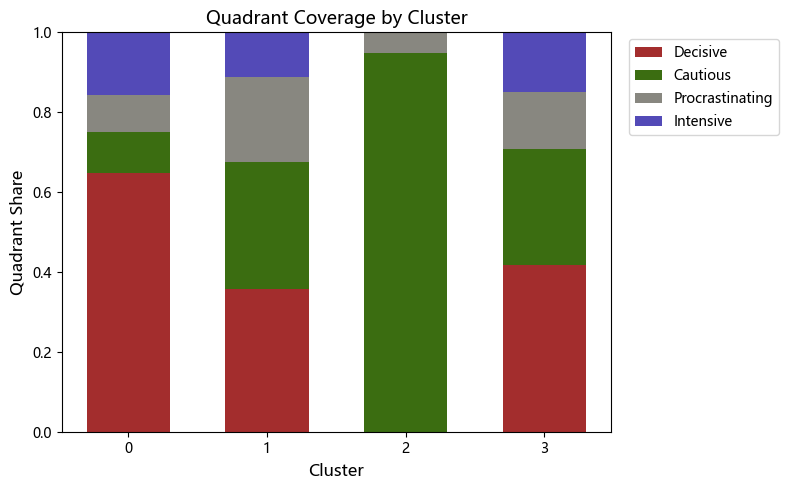

In [18]:
# Visualization: coverage of each Cluster across the four quadrants (100% stacked bar chart)
# Each bar represents one cluster, and within the bar the proportions of that cluster falling into the four
# quadrants are stacked -- this directly shows the pattern behind the crosstab numbers above: Cluster 2 is
# almost a single color (almost entirely Cautious), while Clusters 1/3 are a mix of all four colors (meaning
# the four-quadrant framework has no discriminating power for these two clusters)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
quadrant_colors = {'Decisive': '#A32D2D', 'Cautious': '#3B6D11', 'Procrastinating': '#888780', 'Intensive': '#534AB7'}
bottom = np.zeros(len(crosstab_pct))

for q in quadrant_order:
    ax.bar(crosstab_pct.index.astype(str), crosstab_pct[q], bottom=bottom,
           color=quadrant_colors[q], label=q, width=0.6)
    bottom += crosstab_pct[q].values

ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Quadrant Share', fontsize=12)
ax.set_title('Quadrant Coverage by Cluster', fontsize=13)
ax.legend(fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 11. Cluster Price Profile

In [19]:
# price was already merged into data4 in Section 3 when constructing the core variables, and is used here
# as a post-hoc profile
print(data4.groupby('cluster')['price'].agg(['median', 'mean', 'count']))

# Save events5.csv as the final archived dataset
data4.to_csv('events5.csv', index=False)
print(f"\nevents5.csv saved, {len(data4)} rows, {data4.shape[1]} columns")

          median           mean  count
cluster                               
0        59880.0  125306.910542   4259
1        45000.0  101734.870695   9234
2        48060.0  104865.729880   2162
3        52380.0  119443.991736   1452

events5.csv saved, 18738 rows, 19 columns


## 12. Decision Tree Rule Translation

In [20]:
# The target variable is the Section 9 K-Means cluster label -- this echoes the result of the unsupervised
# learning step, translating the clustering result into business-readable decision rules.
# This is not re-validating whether the clustering is effective (its validity was already confirmed in Section
# 10 with the Kruskal-Wallis test)
# Trained on the raw-scale variables (not log): the numbers in the rules are then thresholds that the business
# can understand directly
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

tree_feat = ['decision_hours', 'research_views', 'total_purchases', 'active_days', 'has_addtocart']
X = data4[tree_feat]
y = data4['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Compare a few depths: "the rules must be usable" means the training performance has to be good enough,
# "the rules must be readable" means the tree cannot be too deep; aim to balance the two
print("=== Accuracy comparison across different depths ===")
for depth in [2, 3, 4, 5]:
    clf_d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_d.fit(X_train, y_train)
    print(f"max_depth={depth}: train_acc={clf_d.score(X_train, y_train):.3f}, "
          f"test_acc={clf_d.score(X_test, y_test):.3f}, leaves={clf_d.get_n_leaves()}")

# Choose max_depth=3: the accuracy is already about 91%, and the number of leaves (7) is still within a range
# a person can follow
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
print(f"\nFinal choice max_depth=3: train_acc={clf.score(X_train, y_train):.3f}, "
      f"test_acc={clf.score(X_test, y_test):.3f}")

persona = {0: 'High-Experience Decision (C0)', 1: 'Lightweight Decision (C1)',
           2: 'High-Friction Decision (C2)', 3: 'No-Add-to-Cart Decision (C3)'}
print("\n=== Decision Rules ===")
print(export_text(clf, feature_names=tree_feat, class_names=[persona[i] for i in sorted(persona)]))

print("=== Feature Importance ===")
for f, imp in sorted(zip(tree_feat, clf.feature_importances_), key=lambda x: -x[1]):
    print(f"{f:20s} {imp:.3f}")

print("\n=== Confusion Matrix (test set, rows=true cluster, columns=predicted cluster) ===")
print(confusion_matrix(y_test, clf.predict(X_test)))

=== Accuracy comparison across different depths ===
max_depth=2: train_acc=0.905, test_acc=0.893, leaves=4
max_depth=3: train_acc=0.919, test_acc=0.913, leaves=7
max_depth=4: train_acc=0.960, test_acc=0.954, leaves=13
max_depth=5: train_acc=0.975, test_acc=0.971, leaves=24

Final choice max_depth=3: train_acc=0.919, test_acc=0.913

=== Decision Rules ===
|--- active_days <= 1.14
|   |--- has_addtocart <= 0.50
|   |   |--- class: No-Add-to-Cart Decision (C3)
|   |--- has_addtocart >  0.50
|   |   |--- decision_hours <= 10.06
|   |   |   |--- class: Lightweight Decision (C1)
|   |   |--- decision_hours >  10.06
|   |   |   |--- class: High-Friction Decision (C2)
|--- active_days >  1.14
|   |--- decision_hours <= 7.25
|   |   |--- total_purchases <= 3.50
|   |   |   |--- class: Lightweight Decision (C1)
|   |   |--- total_purchases >  3.50
|   |   |   |--- class: High-Experience Decision (C0)
|   |--- decision_hours >  7.25
|   |   |--- has_addtocart <= 0.50
|   |   |   |--- class: No-Ad

In [21]:
# Rule translation (business perspective):
# The first step asks "is the pre-decision number of active days greater than 1.14 days", separating "almost
# brand-new visitors" from "people who have already spent some time on the platform"
# (this variable alone has the highest feature importance at 0.451, meaning a single split correctly separates
# more than half of the four decision types)
#
# New visitors (active_days<=1.14 days):
#   First ask "was there an add-to-cart" -- among new visitors, no add-to-cart is almost equivalent to a
#   No-Add-to-Cart Decision (C3); this split is cleaner than asking about decision duration directly
#   If there was an add-to-cart, further split by decision duration: done within 10.06 hours is a Lightweight
#   Decision (C1); taking longer than 10 hours is a High-Friction Decision (C2)
#
# Non-new visitors (active_days>1.14 days):
#   First look at decision duration: done within 7.25 hours, then look at how many times they had purchased
#   before -- more than 3.5 times is a High-Experience Decision (C0), otherwise a Lightweight Decision (C1)
#   Taking longer than 7.25 hours: no add-to-cart is a No-Add-to-Cart Decision (C3, relatively rare but does
#   exist -- an existing user who deliberated for a long time and ultimately never went through the cart),
#   while having added to cart is a High-Friction Decision (C2)
#
# Why does the "new visitor" branch ask "was there an add-to-cart" first rather than decision duration first:
# the decision tree's greedy mechanism means that at each step it only recognizes "which variable + which
# threshold currently splits the cleanest", not a sequence pre-set by business logic. Within the new-visitor
# subgroup, "was there an add-to-cart" happens to be an almost perfect classifier (no add-to-cart almost equals
# C3, i.e. the No-Add-to-Cart Decision), cleaner than any threshold on decision duration, so the algorithm
# picked it first
#
# Why the feature importance of research_views (number of repeat views) is 0: this is mainly a technical
# reason, not a business conclusion that "the number of repeat views does not matter".
# The three variables decision_hours, active_days, and has_addtocart combined can already split the four
# classes very cleanly (91.3% accuracy), so impurity has already dropped very low; meanwhile research_views and
# decision_hours are themselves moderately correlated (Section 8 correlation matrix r=0.523), so decision_hours
# already carries most of research_views's discriminating information -- once the decision tree has used
# decision_hours, what research_views carries is essentially redundant information
# total_purchases also only plays a role in one place (importance 0.050, the >3.5-times branch that separates
# C0/C1), with a very small weight
#
# Plain-language reading of the confusion matrix (rows=true cluster, columns=rule-predicted cluster):
# C0 (High-Experience Decision): 1144 correctly guessed, but 201 mistaken for C1 -- in this part, the
#   High-Experience Decision's purchase count happened to sit right near the 3.5-times threshold, so it did
#   not display the typical "experienced" feature and the rule failed to recognize it
# C1 (Lightweight Decision, the largest group): 3002 correctly guessed, an accuracy of about 97.6%, the most
#   accurately guessed of the four classes -- this type of decision is lightweight on every dimension, so its
#   boundary is the clearest
# C2 (High-Friction Decision): 606 correctly guessed, but 59 mistaken for C1, 27 mistaken for C3, and 4
#   mistaken for C0 -- the class the rules most easily get wrong, meaning this group's simple-rule boundary is
#   not as clean as the other three classes
# C3 (No-Add-to-Cart Decision): 382 correctly guessed, but 50 mistaken for C0 and 56 mistaken for C1 -- about
#   1/5 of No-Add-to-Cart Decisions look, under this simple rule set, much like ordinary purchase decisions,
#   making them boundary cases
# Overall accuracy of 91.3% means this "answerable within four steps" rule set reproduces over 90% of the
# original clustering result

## 13. Subsample Analysis: Browsing Pace and Decision Period (research_views>=2)

In [22]:
# 13.1 Subsample construction: take records with research_views>=2 from events3.csv
# The main analysis (events4/events5) excluded view_interval_mean, but once restricted to research_views>=2,
# every record has at least one genuinely computed browsing interval, so the column regains analytical meaning
# and the relationship between "browsing pace" and decision period can be analyzed separately
data3 = pd.read_csv("events3.csv", parse_dates=['first_trans'])
sub = data3[data3['research_views'] >= 2].copy()
print(f"Subsample size: {len(sub)} records ({len(sub) / len(data3):.1%} of the main analysis sample)")

# 13.2 Construct browsing-regularity variables: view_interval_std / view_interval_cv (coefficient of variation)
# Looking only at the "mean interval" is not enough to characterize "browsing pace" -- this requires
# recomputing the standard deviation from the raw browsing timestamps, then computing the coefficient of
# variation CV = std / mean (dimensionless, unaffected by the scale of the mean interval, so it can be compared
# across users as "regular vs. irregular")
ev2 = pd.read_csv("events2.csv", parse_dates=['timestamp'])
ev2_sub = ev2.merge(sub[['visitorid', 'itemid', 'first_trans']], on=['visitorid', 'itemid'], how='inner')
pre_views = ev2_sub[(ev2_sub['event'] == 'view') & (ev2_sub['timestamp'] < ev2_sub['first_trans'])] \
    .sort_values(['visitorid', 'itemid', 'timestamp'])

def interval_std(g):
    diffs = g['timestamp'].diff().dropna().dt.total_seconds() / 3600
    return diffs.std()

interval_std_df = pre_views.groupby(['visitorid', 'itemid']).apply(interval_std, include_groups=False) \
    .rename('view_interval_std').reset_index()
sub = sub.merge(interval_std_df, on=['visitorid', 'itemid'], how='left')
sub['view_interval_cv'] = np.where(sub['view_interval_mean'] > 0,
                                    sub['view_interval_std'] / sub['view_interval_mean'], np.nan)

# When research_views==2 there is only 1 interval, so the standard deviation is mathematically undefined
# (std() naturally returns NaN for a single value) -- this is the same kind of "structural missingness" as
# view_interval_mean being structurally set to 0 when research_views==1 in Section 3, so the regularity
# analysis needs to be narrowed further to the research_views>=3 subset, leaving only 4445 records
print(f"Structural missingness of view_interval_cv (only 1 interval, research_views=2): {sub['view_interval_cv'].isna().sum()} records, "
      f"proportion {sub['view_interval_cv'].isna().mean():.1%}")

Subsample size: 8500 records (45.4% of the main analysis sample)
Structural missingness of view_interval_cv (only 1 interval, research_views=2): 4445 records, proportion 52.3%


In [23]:
# 13.3 Descriptive statistics + variable transformation
print("=== view_interval_mean (browsing pace: mean interval between consecutive views, hours) ===")
print(sub['view_interval_mean'].describe())
print(f"Skewness: {sub['view_interval_mean'].skew():.3f}")

print(f"\n=== view_interval_cv (browsing regularity: coefficient of variation, n={sub['view_interval_cv'].notna().sum()}) ===")
print(sub['view_interval_cv'].describe())
print(f"Skewness: {sub['view_interval_cv'].skew():.3f}")

# view_interval_mean has noticeable skewness (>1), so apply log1p; CV is a ratio with mild skewness, so it is
# left untransformed
sub['log_view_interval_mean'] = np.log1p(sub['view_interval_mean'])
sub['log_decision_hours'] = np.log1p(sub['decision_hours'])
sub['log_research_views'] = np.log1p(sub['research_views'])

=== view_interval_mean (browsing pace: mean interval between consecutive views, hours) ===
count    8500.000000
mean       23.030903
std       106.010656
min         0.000013
25%         0.039224
50%         0.146735
75%         2.930623
max      2112.175531
Name: view_interval_mean, dtype: float64
Skewness: 10.100

=== view_interval_cv (browsing regularity: coefficient of variation, n=4055) ===
count    4055.000000
mean        1.186320
std         0.591141
min         0.001257
25%         0.786058
50%         1.223244
75%         1.475939
max         6.937427
Name: view_interval_cv, dtype: float64
Skewness: 0.545


In [24]:
# 13.4 Browsing pace (mean interval) and decision period: the correlation is very high, but watch out for
# a constructional overlap
print("=== Correlation: view_interval_mean vs decision_hours ===")
print(f"Raw values: r = {sub['view_interval_mean'].corr(sub['decision_hours']):.3f}")
print(f"log-log: r = {sub['log_view_interval_mean'].corr(sub['log_decision_hours']):.3f}")

# Note: a duplication issue corresponding to collinearity
# This high correlation merely reflects the identity-level mathematical relationship
# "decision period = view interval x (number of repeat views - 1)", and produces no extra information
# After controlling for research_views, check whether R^2 is still abnormally high (if so, it confirms the
# overlap is indeed at the level of an identity):
X_pace = sm.add_constant(sub[['log_view_interval_mean', 'log_research_views']])
ols_pace = sm.OLS(sub['log_decision_hours'], X_pace).fit()
print(ols_pace.summary())

=== Correlation: view_interval_mean vs decision_hours ===
Raw values: r = 0.788
log-log: r = 0.943
                            OLS Regression Results                            
Dep. Variable:     log_decision_hours   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 5.530e+04
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:33:13   Log-Likelihood:                -6254.4
No. Observations:                8500   AIC:                         1.251e+04
Df Residuals:                    8497   BIC:                         1.254e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------

In [25]:
# 13.5 Browsing regularity (CV) and decision period: research_views>=3
from scipy.stats import spearmanr, kruskal

sub_reg = sub.dropna(subset=['view_interval_cv']).copy()
print(f"Regularity-analysis subset: n={len(sub_reg)}")

print("\n=== Correlation: view_interval_cv vs decision_hours ===")
print(f"Raw values: r = {sub_reg['view_interval_cv'].corr(sub_reg['decision_hours']):.3f}")
print(f"vs log_decision_hours: r = {sub_reg['view_interval_cv'].corr(sub_reg['log_decision_hours']):.3f}")
rho, p_rho = spearmanr(sub_reg['view_interval_cv'], sub_reg['decision_hours'])
print(f"Spearman rank correlation (does not rely on a linearity assumption, a robustness check): rho = {rho:.3f}, p = {p_rho:.4g}")

# CV is almost uncorrelated with view_interval_mean, meaning "regularity" is a dimension independent of
# "how fast the pace is"
print(f"\nCorrelation between CV and view_interval_mean: {sub_reg['view_interval_cv'].corr(sub_reg['view_interval_mean']):.3f}")

# Group by median: Regular (low CV) vs. Irregular (high CV)
median_cv = sub_reg['view_interval_cv'].median()
sub_reg['regularity_group'] = np.where(sub_reg['view_interval_cv'] <= median_cv, 'Regular(Low CV)', 'Irregular(High CV)')

print("\n=== Decision period comparison between the two groups ===")
print(sub_reg.groupby('regularity_group')['decision_hours'].agg(['median', 'mean', 'count']))

stat, p = kruskal(sub_reg.loc[sub_reg['regularity_group'] == 'Regular(Low CV)', 'decision_hours'],
                   sub_reg.loc[sub_reg['regularity_group'] == 'Irregular(High CV)', 'decision_hours'])
print(f"\nKruskal-Wallis: H={stat:.2f}, p={p:.4g} (significant: {p < 0.05})")

# Net effect of CV on decision period after controlling for research_views (R^2 is far lower than in Section
# 13.4, meaning this is not an identity-level relationship)
X_reg = sm.add_constant(sub_reg[['view_interval_cv', 'log_research_views']])
ols_reg = sm.OLS(sub_reg['log_decision_hours'], X_reg).fit()
print(ols_reg.summary())

Regularity-analysis subset: n=4055

=== Correlation: view_interval_cv vs decision_hours ===
Raw values: r = 0.216
vs log_decision_hours: r = 0.508
Spearman rank correlation (does not rely on a linearity assumption, a robustness check): rho = 0.611, p = 0

Correlation between CV and view_interval_mean: 0.111

=== Decision period comparison between the two groups ===
                       median        mean  count
regularity_group                                
Irregular(High CV)  21.363078  123.266530   2027
Regular(Low CV)      0.433737   30.852673   2028

Kruskal-Wallis: H=1285.17, p=1.885e-281 (significant: True)
                            OLS Regression Results                            
Dep. Variable:     log_decision_hours   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     729.7
Date:                Wed, 24 Jun 2026   Prob (F-statistic):

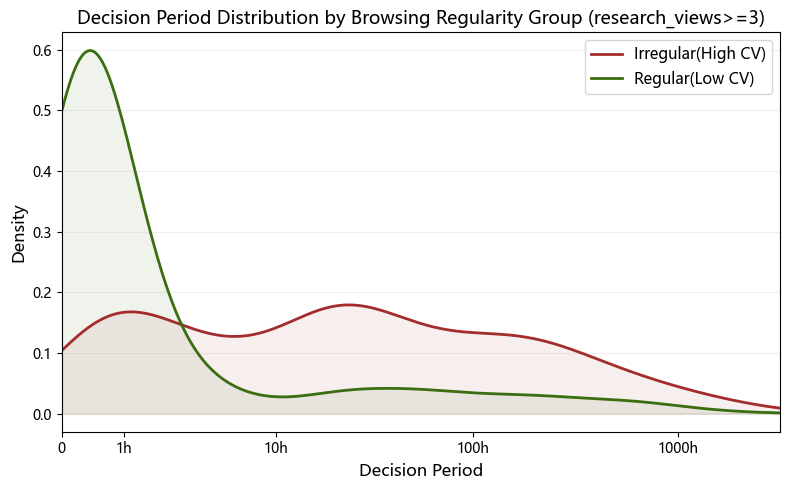

In [26]:
# 13.6 Visualization: comparison of the decision-period distribution between the Regular and Irregular groups
# (log scale, ticks converted back to raw hours)
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(8, 5))
colors_reg = {'Regular(Low CV)': '#3B6D11', 'Irregular(High CV)': '#A32D2D'}
xs = np.linspace(0, sub_reg['log_decision_hours'].max(), 300)

for grp_name, grp in sub_reg.groupby('regularity_group'):
    kde = gaussian_kde(grp['log_decision_hours'], bw_method=0.3)
    ax.plot(xs, kde(xs), color=colors_reg[grp_name], linewidth=2, label=grp_name)
    ax.fill_between(xs, kde(xs), alpha=0.08, color=colors_reg[grp_name])

tick_vals = [0, np.log1p(1), np.log1p(10), np.log1p(100), np.log1p(1000)]
tick_labels = ['0', '1h', '10h', '100h', '1000h']
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_labels)
ax.set_xlim(0, sub_reg['log_decision_hours'].max())

ax.set_xlabel('Decision Period', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Decision Period Distribution by Browsing Regularity Group (research_views>=3)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [27]:
# 13.7 Summary
# Browsing pace (view_interval_mean) is highly correlated with decision period (log-log r=0.943, OLS
# R^2=0.929); this is not an independent behavioral finding, and is kept only as an intermediate variable used
# to construct CV
#
# Browsing regularity (view_interval_cv) is a more genuinely independent signal: CV is almost uncorrelated with
# view_interval_mean (r=0.111); the regular group's median decision period is only 0.43h, while the irregular
# group's median reaches 21.4h, a difference of nearly 50x, and the Kruskal-Wallis test is highly significant
# (H=1285.17, p<0.001)
#
# Business interpretation: for two users with a similar number of views and a similar mean interval, if the
# browsing pace is continuous and concentrated (Regular), the purchase is usually completed on the spot or the
# same day; if there are long gaps interspersed between views (Irregular, e.g. viewing once and coming back
# days later), the decision period is greatly stretched out. This kind of "gapped revisit" pattern may reflect
# that the user experienced hesitation during the gap between views, compared off-platform information, or
# needed to be re-activated after their purchase intent was interrupted -- echoing Section 12's Sub-Hypothesis
# 2 (corresponding to the High-Friction Decision) diagnosis of the friction source behind "Cautious" users;
# the irregularity of browsing pace can serve as a candidate behavioral signal for identifying users who are
# "still hesitating and need to be re-activated", more fine-grained than the raw number of repeat views
# (research_views) alone, and can be used to design the trigger timing for win-back-style interventions
#
# Limitations: covers only research_views>=2 (45.4% of the sample); CV further requires research_views>=3
# (21.6% of the sample), so the sample size shrinks and statistical power drops; the analysis is still a
# post-hoc association and does not constitute causal evidence